# Task 3 — Model 3: GRU (neural network)

One-step-ahead forecasts for the same three squares and **test week (16–22 Dec 2013)**. Same train/test split as ARIMA and LSTM. **One model per square.**

In [1]:
# Core libraries
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Reproducibility and CPU device
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cpu")

In [3]:
# Paths and time windows (aligned with ARIMA / LSTM)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET_PATH = PROJECT_ROOT / "data" / "processed" / "milan_internet_traffic.parquet"
FOCUS_PATH = PROJECT_ROOT / "data" / "processed" / "task2_focus_squares.csv"
FIG_DIR = PROJECT_ROOT / "figures" / "task3_gru"
OUT_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_START, TRAIN_END = "2013-11-01", "2013-12-16"
TEST_START, TEST_END = "2013-12-16", "2013-12-23"

In [4]:
# Hyperparameters (same protocol as LSTM for fair comparison)
SEQ_LEN = 144          # one day of 10-minute history
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.1
EPOCHS = 25
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
VAL_FRACTION = 0.1

In [5]:
# Focus squares from Task 2
focus = pd.read_csv(FOCUS_PATH)
SQUARE_IDS = focus["square_id"].tolist()
LABELS = dict(zip(focus["square_id"], focus["label"]))
print(focus)

         label  square_id
0      highest       5161
1  square_4159       4159
2  square_4556       4556


## Model description (for report)

**GRU** (Gated Recurrent Unit) is a recurrent network similar to LSTM but with fewer gates:
- **Input:** last `SEQ_LEN` = 144 traffic values (10-minute resolution).
- **Preprocessing:** `MinMaxScaler` on training data only.
- **Architecture:** 2-layer GRU (hidden 64) → linear output (one-step).
- **Training:** sliding windows, Adam + MSE, early stopping on validation loss.
- **Test:** one-step-ahead with true history up to each \(t\).

In [6]:
# Load three squares once
traffic = pd.read_parquet(PARQUET_PATH)
traffic = traffic[traffic["square_id"].isin(SQUARE_IDS)]
print(f"Subset rows: {len(traffic):,}")

Subset rows: 26,784


In [7]:
def series_for_square(square_id: int, t0: str, t1: str) -> pd.Series:
    """Regular 10-minute series for one square in [t0, t1)."""
    chunk = traffic[(traffic["square_id"] == square_id) & (traffic["time"] >= t0) & (traffic["time"] < t1)]
    s = chunk.set_index("time")["internet"].sort_index()
    idx = pd.date_range(t0, t1, freq="10min", inclusive="left")
    return s.reindex(idx, fill_value=0).astype(float)

In [8]:
def make_supervised_windows(series_1d: np.ndarray, seq_len: int):
    """Build (X, y): past seq_len values → next value."""
    X, y = [], []
    for i in range(len(series_1d) - seq_len):
        X.append(series_1d[i : i + seq_len])
        y.append(series_1d[i + seq_len])
    X = np.array(X, dtype=np.float32)[:, :, None]
    y = np.array(y, dtype=np.float32)[:, None]
    return X, y

In [9]:
class GRUForecaster(nn.Module):
    """Stacked GRU + linear head for one-step prediction."""

    def __init__(self, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])

In [10]:
def prepare_training_data(train_series: pd.Series):
    """Scale and split into train / validation loaders."""
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(train_series.values.reshape(-1, 1)).flatten()
    X, y = make_supervised_windows(scaled, SEQ_LEN)
    n_val = max(1, int(len(X) * VAL_FRACTION))
    loader = DataLoader(
        TensorDataset(torch.tensor(X[:-n_val]), torch.tensor(y[:-n_val])),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    val_X, val_y = torch.tensor(X[-n_val:]), torch.tensor(y[-n_val:])
    return scaler, loader, val_X, val_y

In [11]:
def fit_gru_model(train_loader, val_X, val_y):
    """Train GRU with early stopping on validation MSE."""
    model = GRUForecaster(HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()
    best_val, best_state, bad = np.inf, None, 0
    t0 = time.perf_counter()
    for _ in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE)).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            vloss = loss_fn(model(val_X.to(DEVICE)), val_y.to(DEVICE)).item()
        if vloss < best_val:
            best_val, best_state, bad = vloss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= 5:
                break
    model.load_state_dict(best_state)
    return model, time.perf_counter() - t0

In [12]:
def train_gru(train_series: pd.Series):
    """Full training pipeline for one square."""
    scaler, loader, val_X, val_y = prepare_training_data(train_series)
    model, train_sec = fit_gru_model(loader, val_X, val_y)
    return model, scaler, train_sec

In [13]:
def forecast_test_week(model, scaler, train: pd.Series, test: pd.Series):
    """One-step-ahead using true history (train + actual test values)."""
    model.eval()
    history = train.values.astype(float).tolist()
    preds = []
    t0 = time.perf_counter()
    for actual in test.values:
        window = np.array(history[-SEQ_LEN:], dtype=np.float32).reshape(-1, 1)
        w_scaled = scaler.transform(window).flatten()
        x = torch.tensor(w_scaled.reshape(1, SEQ_LEN, 1)).to(DEVICE)
        with torch.no_grad():
            p_scaled = model(x).cpu().numpy().ravel()[0]
        preds.append(float(scaler.inverse_transform([[p_scaled]])[0, 0]))
        history.append(float(actual))
    return pd.Series(preds, index=test.index, name="predicted"), time.perf_counter() - t0

In [14]:
def error_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """MAE, MAPE (%), RMSE."""
    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    denom = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs(err / denom)) * 100
    rmse = np.sqrt(np.mean(err ** 2))
    return {"MAE": mae, "MAPE": mape, "RMSE": rmse}

## Train and evaluate — all three areas

In [15]:
results = {}
metrics = []
timings = []

for sq in SQUARE_IDS:
    train = series_for_square(sq, TRAIN_START, TRAIN_END)
    test = series_for_square(sq, TEST_START, TEST_END)
    model, scaler, train_sec = train_gru(train)
    pred, forecast_sec = forecast_test_week(model, scaler, train, test)
    m = error_metrics(test.values, pred.values)
    m.update({"square_id": sq, "label": LABELS[sq], "model": "GRU"})
    metrics.append(m)
    timings.append({"square_id": sq, "train_sec": train_sec, "forecast_sec": forecast_sec})
    results[sq] = pd.DataFrame({"actual": test, "predicted": pred})
    print(f"Square {sq}: train {train_sec:.1f}s, forecast {forecast_sec:.1f}s, MAE={m['MAE']:.2f}")

Square 5161: train 596.3s, forecast 54.2s, MAE=85.91
Square 4159: train 807.7s, forecast 54.7s, MAE=15.10
Square 4556: train 1386.3s, forecast 53.0s, MAE=26.55


In [16]:
metrics_df = pd.DataFrame(metrics)[["label", "square_id", "model", "MAE", "MAPE", "RMSE"]]
display(metrics_df)
metrics_df.to_csv(OUT_DIR / "gru_metrics_by_area.csv", index=False)

,label,square_id,model,MAE,MAPE,RMSE
0,highest,5161,GRU,85.912388,9.276562,127.319194
1,square_4159,4159,GRU,15.095180,6.840837,20.187448
2,square_4556,4556,GRU,26.548396,6.107631,35.608516


In [17]:
timing_df = pd.DataFrame(timings)
timing_df["hardware"] = platform.platform()
timing_df["python"] = platform.python_version()
timing_df["seq_len"] = SEQ_LEN
display(timing_df)
timing_df.to_csv(OUT_DIR / "gru_timings.csv", index=False)

,square_id,train_sec,forecast_sec,hardware,python,seq_len
0,5161,596.255389,54.215458,Windows-11-10.0.26100-SP0,3.14.0,144
1,4159,807.732488,54.725976,Windows-11-10.0.26100-SP0,3.14.0,144
2,4556,1386.341413,53.038894,Windows-11-10.0.26100-SP0,3.14.0,144


## Plots — actual vs GRU (test week)

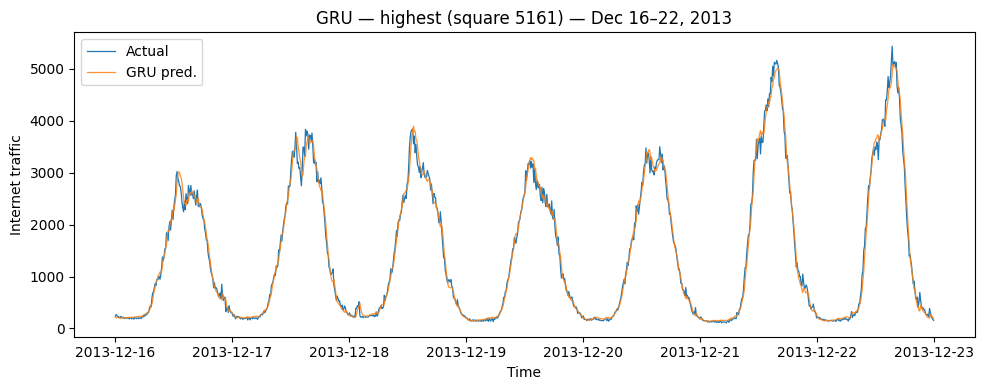

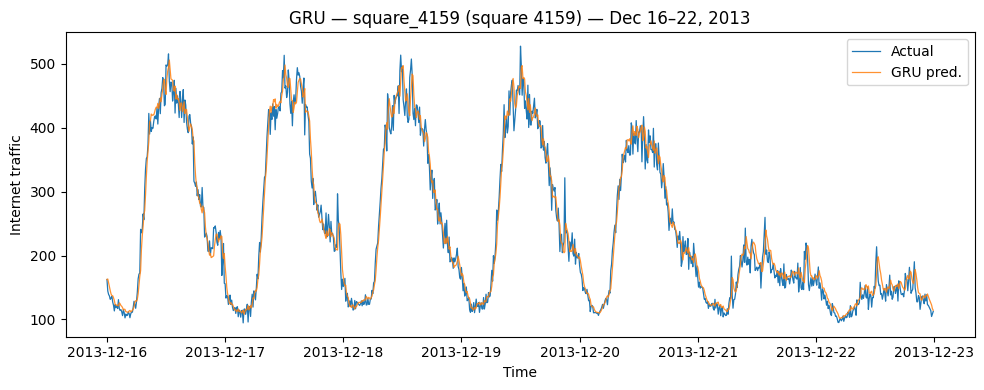

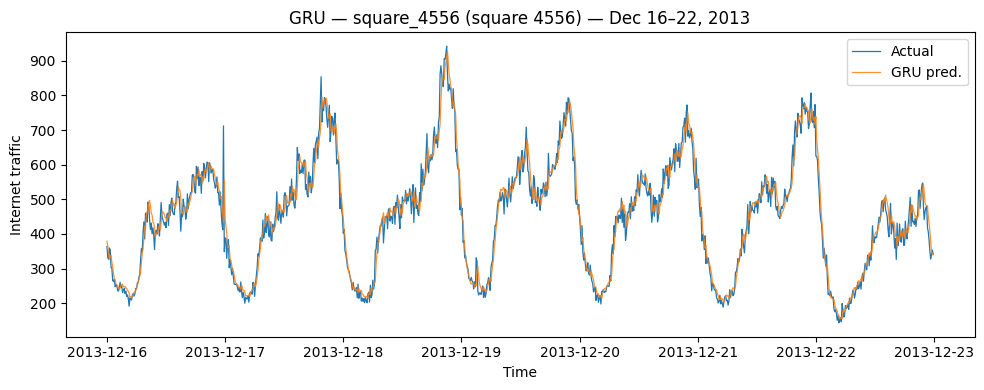

In [18]:
for sq in SQUARE_IDS:
    df = results[sq]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df.index, df["actual"], label="Actual", linewidth=0.9)
    ax.plot(df.index, df["predicted"], label="GRU pred.", linewidth=0.9, alpha=0.85)
    ax.set_title(f"GRU — {LABELS[sq]} (square {sq}) — Dec 16–22, 2013")
    ax.set_xlabel("Time")
    ax.set_ylabel("Internet traffic")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"gru_square_{sq}.png", dpi=150)
    plt.show()

In [19]:
# Save predictions for three-model comparison
for sq, df in results.items():
    path = OUT_DIR / f"gru_predictions_square_{sq}.csv"
    df.to_csv(path)
    print(f"Saved {path.name}")

Saved gru_predictions_square_5161.csv
Saved gru_predictions_square_4159.csv
Saved gru_predictions_square_4556.csv


## Comparison note (report)

Merge `arima_metrics_by_area.csv`, `lstm_metrics_by_area.csv`, and `gru_metrics_by_area.csv` for the three tables required in Task 3. GRU vs LSTM: similar recurrent structure; GRU has **fewer parameters** and often trains slightly faster with comparable accuracy on smooth seasonal series.